In [1]:
import scipy
import random
import numpy as np
import pandas as pd
#import seaborn as sns
from matplotlib import pyplot as plt
from numba import jit

from scipy.stats import ks_1samp
from scipy.stats import norm, kstest
from scipy.stats import kstest
from scipy.stats import ttest_ind
from scipy.stats import ks_2samp
from scipy.stats import gaussian_kde

from scipy.optimize import minimize
from scipy.spatial import distance
from scipy.integrate import quad

from source.distributions import *
from source.plot_tools import *
from source.analysis_tools import *

In [2]:
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Arial']})
# rc('text', usetex=True)
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15
plt.rcParams['font.size']=15
plt.rcParams['pdf.fonttype']=42
plt.rcParams["text.usetex"]=False

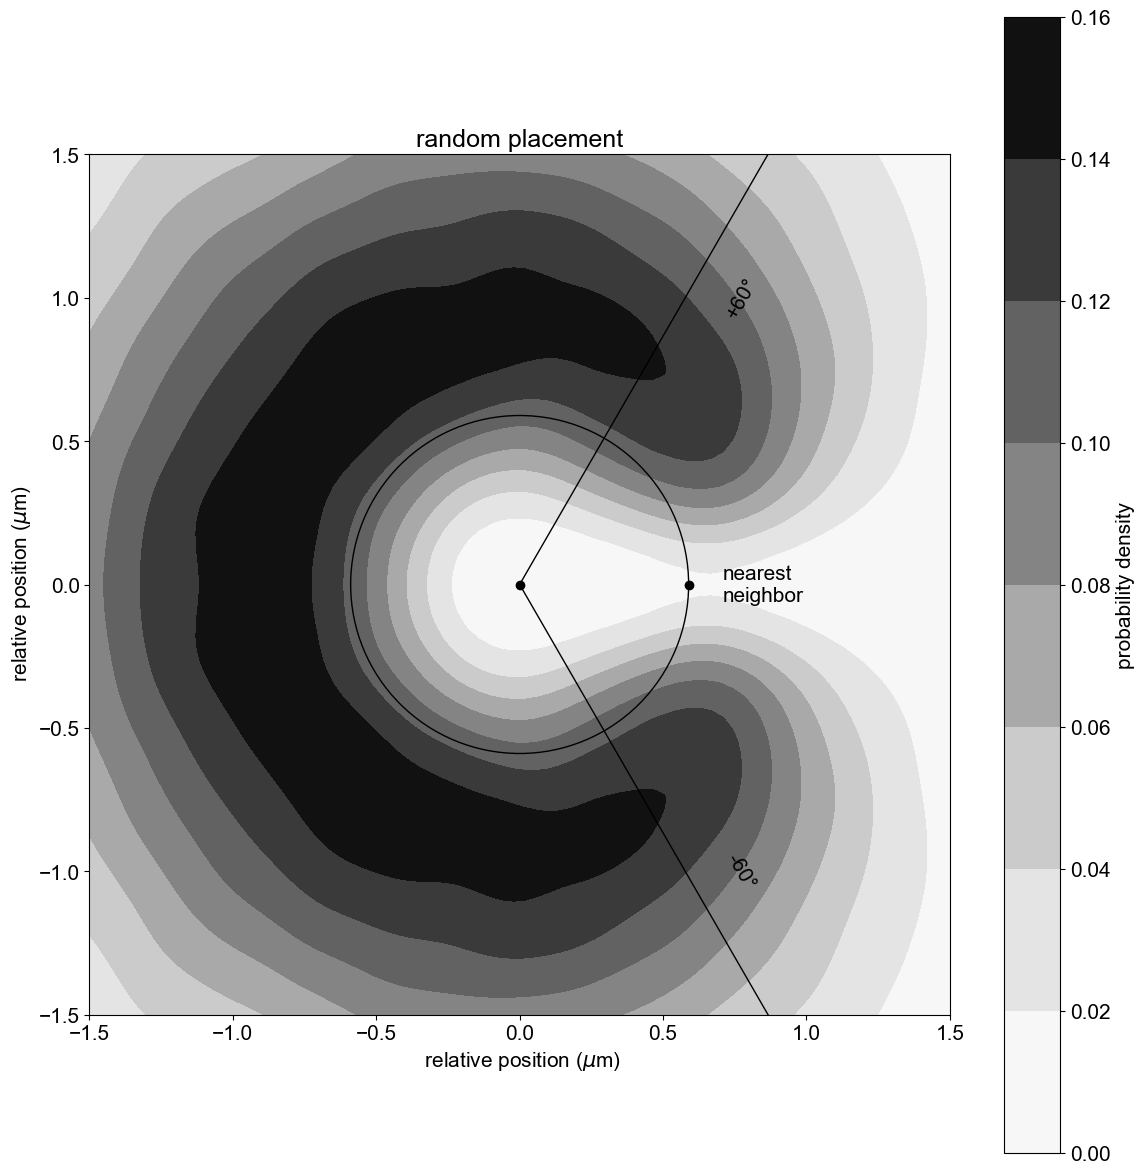

In [3]:
# this corresponds to hard spheres wiggling around

@jit
def move(points, idx, dx):
    for i, dist in enumerate(points - points[idx] - dx):
        if i == idx:
            continue
        elif dist[0]**2 + dist[1]**2 < R**2:
            return
        elif abs(points[idx,0] + dx[0]) > L or abs(points[idx,1] + dx[1]) > L:
            return
    points[idx] += dx

#@jit
def step(points, update_list):
    for idx in update_list:
        dx    = 0.1*R*(np.random.randn(2))
        move(points, idx, dx)
            
fig, ax = plt.subplots(1, 1, figsize=(12,12))

# random placement

L = 7.5
R = 0.25
N = int((2*L)**2 * np.sqrt(3)*np.pi/6)

num_neighbors_artificial = []
nearest_distances_artificial = []
rotated_coordinates_artificial = []

for _ in range(10):
    points = []
    while len(points) < N:
        x = np.random.uniform(-L, L, size=2)
        if points == [] or np.all(np.linalg.norm(np.stack(points) - x, axis=-1) > R):
            points.append(x)
    points = np.stack(points)

    # relaxation:
    for _ in range(10000):
        update_list = list(range(N))
        np.random.shuffle(update_list)
        step(points, update_list)

    for _ in range(10):
        for _ in range(1000):
            update_list = list(range(N))
            np.random.shuffle(update_list)
            step(points, update_list)
    
        num_neighbors_inner, nearest_distances_inner, _, rotated_coordinates_inner = analyze_pointcloud(points)
        num_neighbors_artificial += num_neighbors_inner
        nearest_distances_artificial += nearest_distances_inner
        rotated_coordinates_artificial += rotated_coordinates_inner
    
rotated_coordinates_artificial = np.stack(rotated_coordinates_artificial)
nearest_distances_artificial = np.stack(nearest_distances_artificial)

plot_density(fig, ax, rotated_coordinates_artificial, np.mean(nearest_distances_artificial), L=2)
ax.set_title("random placement")

fig.tight_layout()